# 🐾 PetOS — Modelo de IA para Priorização de Risco de Saúde

**Projeto:** CLYVO VET / PetOS — Challenge de Inteligência Artificial
**Componente:** Modelo preditivo de classificação de risco de saúde a partir dos dados da coleira IoT (ESP32 + DHT22 + PIR)

## Contexto

O protótipo IoT (coleira inteligente) hoje funciona com **limiares fixos**: se a temperatura ultrapassa 35°C ou a umidade sai de uma faixa, o sistema dispara um alerta genérico, igual para qualquer animal.

Isso tem três limitações que motivam este notebook:

1. **Um limiar único não serve para todo animal.** Um filhote, um idoso e um animal silvestre (ex: uma ave em reabilitação) têm faixas fisiológicas normais diferentes.
2. **O alerta não tem prioridade nem contexto.** O tutor recebe "atenção necessária" sem saber a gravidade nem o que fazer.
3. **O sistema não aprende com o histórico** nem se ajusta ao perfil do animal.

**Objetivo deste notebook:** treinar um modelo de classificação que recebe as leituras da coleira (temperatura, umidade, atividade) + o perfil do animal (espécie, porte, idade) e retorna um **nível de risco personalizado**: `normal`, `atencao` ou `critico`. Esse modelo será servido depois via API (Flask + Docker, mesmo fluxo usado na CP4).

> **Nota sobre os dados:** não existe um dataset público pronto que combine sensores IoT (temperatura/umidade/movimento) + espécie + rótulo de risco veterinário. Por isso, este notebook **gera um dataset sintético de forma documentada e reprodutível** (seed fixa), a partir de faixas fisiológicas de referência definidas por espécie. Isso resolve o problema de rastreabilidade: todo o pipeline — da origem do dado até o modelo final — está neste único arquivo.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
np.random.seed(42)


## 1. Geração do Dataset Sintético

### 1.1 Premissas fisiológicas por espécie

Definimos, para cada espécie (**cão**, **gato**, **ave silvestre em reabilitação**), faixas de referência para três sinais capturados pela coleira:

- **Temperatura corporal (°C)**
- **Umidade relativa do ambiente/pelagem (%)** — proxy indireto de conforto térmico, capturado pelo DHT22
- **% de atividade** — proporção de tempo com movimento detectado (PIR) numa janela de observação

Cada sinal é dividido em 5 zonas por 4 pontos de corte `[crítico_baixo, atenção_baixo, atenção_alto, crítico_alto]`:

`crítico | atenção | normal | atenção | crítico`

> **Réptil silvestre ficou fora do escopo deste modelo de propósito.** Répteis são ectotérmicos — não regulam a própria temperatura corporal, ela depende do ambiente/terrário. Misturar essa lógica com endotérmicos (cão/gato/ave) invalidaria as mesmas regras de rótulo. Fica documentado como próxima etapa: um modelo específico para répteis, considerando temperatura ambiente controlada.

### 1.2 Personalização por idade

Filhotes e idosos têm menor reserva fisiológica — por isso, temos **menos tolerância a desvios**: aplicamos um fator que "aperta" as zonas normais/atenção em ~15% para essas faixas etárias, tornando o modelo mais sensível para animais mais vulneráveis.


In [2]:
# breakpoints = [crit_low, aten_low, aten_high, crit_high]
SPECIES_CONFIG = {
    "cao": {
        "temperatura": [15, 20, 35, 38],
        "umidade":     [15, 30, 70, 85],
        "atividade":   [10, 25, 100, 101],   # variável one-sided: só baixa atividade preocupa
    },
    "gato": {
        "temperatura": [15, 20, 34, 37],
        "umidade":     [15, 30, 70, 85],
        "atividade":   [5, 15, 100, 101],    # gato dorme mais por natureza: mais tolerante
    },
    "ave": {
        "temperatura": [20, 25, 39, 42],
        "umidade":     [25, 40, 75, 90],
        "atividade":   [20, 35, 100, 101],   # aves escondem doença: inatividade é sinal mais grave
    },
}

AGE_FACTOR = {"filhote": 0.85, "adulto": 1.0, "idoso": 0.85}
PORTE_OPCOES = {"cao": ["pequeno", "medio", "grande"], "gato": ["unico"], "ave": ["unico"]}
LABEL_MAP = {0: "normal", 1: "atencao", 2: "critico"}


def scale_breakpoints(bp, factor, one_sided=False):
    """Ajusta os pontos de corte de acordo com o fator de idade.
    Para variáveis one-sided (atividade), aperta apenas o piso mínimo exigido.
    Para variáveis two-sided (temperatura/umidade), aperta a zona em torno do centro.
    """
    crit_low, aten_low, aten_high, crit_high = bp
    if one_sided:
        return [crit_low / factor, aten_low / factor, aten_high, crit_high]
    center = (aten_low + aten_high) / 2
    return [
        center - (center - crit_low) * factor,
        center - (center - aten_low) * factor,
        center + (aten_high - center) * factor,
        center + (crit_high - center) * factor,
    ]


def status_from_value(value, bp):
    """Classifica um valor em 0=normal, 1=atenção, 2=crítico segundo os breakpoints."""
    crit_low, aten_low, aten_high, crit_high = bp
    if value < crit_low or value > crit_high:
        return 2
    if value < aten_low or value > aten_high:
        return 1
    return 0


def sample_value_in_zone(zone, bp, one_sided=False):
    """Sorteia um valor plausível dentro de uma zona específica (normal/atenção/crítico)."""
    crit_low, aten_low, aten_high, crit_high = bp
    if zone == 0:
        return np.random.uniform(aten_low, aten_high)
    if zone == 1:
        if one_sided:
            return np.random.uniform(crit_low, aten_low)
        side = np.random.choice(["low", "high"])
        return np.random.uniform(crit_low, aten_low) if side == "low" else np.random.uniform(aten_high, crit_high)
    # zone == 2 (crítico)
    if one_sided:
        return np.random.uniform(max(0, crit_low - 10), crit_low)
    side = np.random.choice(["low", "high"])
    return (np.random.uniform(max(0, crit_low - 5), crit_low) if side == "low"
            else np.random.uniform(crit_high, crit_high + 5))


### 1.3 Função de geração do dataset

Lógica de cada linha gerada:

1. Sorteia espécie, porte e idade do animal.
2. Sorteia uma **severidade-alvo** (proporção aproximada: 70% normal, 19% atenção, 9% crítico — refletindo que, na maior parte do tempo, o animal está bem).
3. Escolhe aleatoriamente **qual variável** (temperatura, umidade ou atividade) vai carregar essa severidade — as outras duas variam com leve chance de também se desviarem (ruído realista).
4. O **rótulo final** é o pior caso (`max`) entre as três variáveis — assim como um veterinário olharia: um único sinal vital alterado já levanta alerta, mesmo que os outros estejam normais.
5. Aplicamos ruído adicional em ~6% das linhas, subindo ou descendo 1 nível de risco — simula ambiguidade real de casos-limite e evita um dataset "perfeito demais".


In [3]:
def gerar_dataset(n=4000, seed=42):
    rng = np.random.default_rng(seed)
    especies = list(SPECIES_CONFIG.keys())
    linhas = []

    for _ in range(n):
        especie = rng.choice(especies, p=[0.45, 0.35, 0.20])
        idade = rng.choice(["filhote", "adulto", "idoso"], p=[0.2, 0.6, 0.2])
        porte = rng.choice(PORTE_OPCOES[especie])
        severidade_alvo = rng.choice([0, 1, 2], p=[0.72, 0.19, 0.09])

        factor = AGE_FACTOR[idade]
        cfg = SPECIES_CONFIG[especie]
        bp_temp = scale_breakpoints(cfg["temperatura"], factor)
        bp_umid = scale_breakpoints(cfg["umidade"], factor)
        bp_ativ = scale_breakpoints(cfg["atividade"], factor, one_sided=True)

        driver = rng.choice(["temperatura", "umidade", "atividade"])

        def gerar_var(nome, bp, one_sided=False):
            if nome == driver:
                zona = severidade_alvo
            else:
                zona = rng.choice([0, 1, 2], p=[0.92, 0.07, 0.01])
            return sample_value_in_zone(zona, bp, one_sided=one_sided)

        temperatura = gerar_var("temperatura", bp_temp)
        umidade = gerar_var("umidade", bp_umid)
        atividade = float(np.clip(gerar_var("atividade", bp_ativ, one_sided=True), 0, 100))

        severidade_final = max(
            status_from_value(temperatura, bp_temp),
            status_from_value(umidade, bp_umid),
            status_from_value(atividade, bp_ativ),
        )

        linhas.append({
            "especie": especie,
            "porte": porte,
            "idade_categoria": idade,
            "temperatura": round(float(temperatura), 2),
            "umidade": round(float(umidade), 2),
            "atividade_pct": round(atividade, 2),
            "nivel_risco": LABEL_MAP[severidade_final],
        })

    df = pd.DataFrame(linhas)

    # ruído: ambiguidade real de casos-limite (~6% das linhas sobem/descem 1 nível)
    idx_ruido = df.sample(frac=0.06, random_state=seed).index
    ordem = ["normal", "atencao", "critico"]
    for i in idx_ruido:
        atual = ordem.index(df.loc[i, "nivel_risco"])
        novo = int(np.clip(atual + rng.choice([-1, 1]), 0, 2))
        df.loc[i, "nivel_risco"] = ordem[novo]

    return df


df = gerar_dataset(n=4000, seed=42)
df.to_csv("dataset_sintetico_petos.csv", index=False)
print("Shape:", df.shape)
df.head()


Shape: (4000, 7)


,especie,porte,idade_categoria,temperatura,umidade,atividade_pct,nivel_risco
0,gato,unico,adulto,18.98,37.34,12.80,atencao
1,gato,unico,adulto,28.36,47.83,23.50,normal
2,ave,unico,adulto,31.43,34.02,81.02,atencao
3,cao,medio,idoso,21.39,65.98,26.45,atencao
4,ave,unico,adulto,27.97,46.36,46.92,normal


## 2. Análise Exploratória

Antes de treinar, vale conferir se a distribuição de classes e as variáveis fazem sentido — nem perfeitamente separável demais, nem desbalanceada a ponto de o modelo só aprender a classe majoritária.


In [4]:
print("Distribuição geral do nível de risco:")
print(df["nivel_risco"].value_counts(normalize=True).round(3))

print("\nDistribuição por espécie:")
print(df.groupby("especie")["nivel_risco"].value_counts(normalize=True).round(3))

df[["temperatura", "umidade", "atividade_pct"]].describe()


Distribuição geral do nível de risco:
nivel_risco
normal     0.599
atencao    0.283
critico    0.118
Name: proportion, dtype: float64

Distribuição por espécie:
especie  nivel_risco
ave      normal         0.617
         atencao        0.274
         critico        0.109
cao      normal         0.590
         atencao        0.293
         critico        0.116
gato     normal         0.599
         atencao        0.274
         critico        0.126
Name: proportion, dtype: float64


,temperatura,umidade,atividade_pct
count,4000.000000,4000.000000,4000.000000
mean,28.006560,51.615980,55.828088
std,5.564233,15.046838,26.879248
min,10.220000,10.030000,0.010000
25%,24.050000,40.875000,34.567500
50%,28.105000,51.700000,56.950000
75%,32.030000,62.285000,78.687500
max,46.020000,93.970000,99.970000


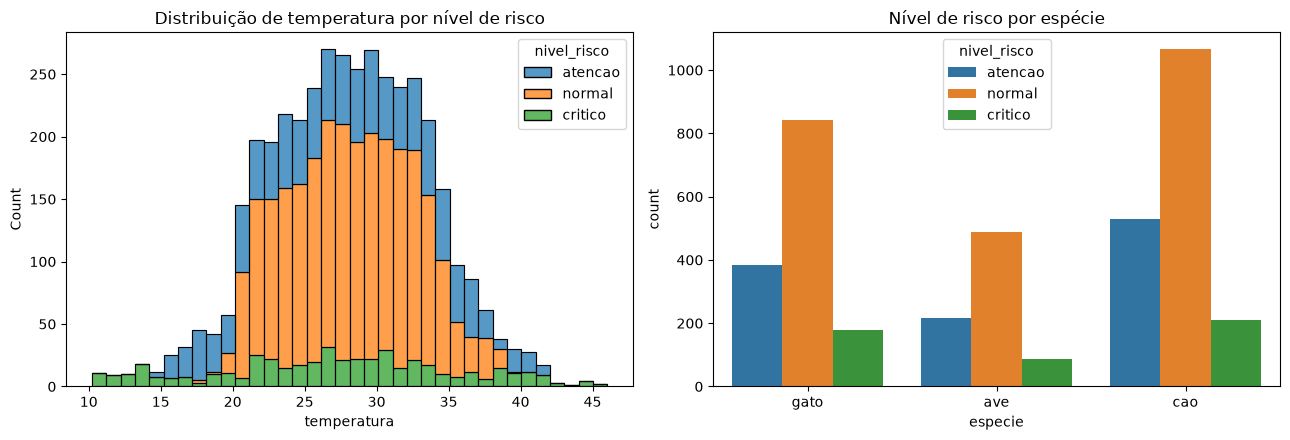

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(data=df, x="temperatura", hue="nivel_risco", multiple="stack", ax=axes[0])
axes[0].set_title("Distribuição de temperatura por nível de risco")

sns.countplot(data=df, x="especie", hue="nivel_risco", ax=axes[1])
axes[1].set_title("Nível de risco por espécie")

plt.tight_layout()
plt.show()


## 3. Pré-processamento e Divisão Treino/Teste

Features categóricas (`especie`, `porte`, `idade_categoria`) precisam virar variáveis binárias (one-hot). As numéricas (`temperatura`, `umidade`, `atividade_pct`) já entram como estão — `RandomForest` não exige normalização/escala.

Usamos `stratify=y` para manter a mesma proporção de classes no treino e no teste, já que o dataset é desbalanceado (mais casos normais do que críticos, como na realidade).


In [6]:
from sklearn.model_selection import train_test_split

FEATURES_CATEGORICAS = ["especie", "porte", "idade_categoria"]
FEATURES_NUMERICAS = ["temperatura", "umidade", "atividade_pct"]

X = df[FEATURES_CATEGORICAS + FEATURES_NUMERICAS]
y = df["nivel_risco"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_train.shape, " Teste:", X_test.shape)


Treino: (3200, 6)  Teste: (800, 6)


## 4. Treinamento do Modelo

**Escolha do algoritmo: Random Forest.** Justificativa técnica:

- Lida bem com **features mistas** (categóricas + numéricas) sem exigir normalização.
- É **robusto a relações não-lineares** — nossas zonas de risco não são lineares (ex: tanto temperatura muito alta quanto muito baixa são críticas).
- Fornece **importância de features nativamente**, o que ajuda a explicar as decisões do modelo para o time e, futuramente, para o tutor/clínica (explicabilidade é importante em saúde).
- É **menos sensível a overfitting** que uma única árvore de decisão, e não exige tanto dado quanto uma rede neural — adequado ao volume do nosso dataset sintético.
- `class_weight="balanced"` compensa o desbalanceamento entre as classes (poucos casos críticos, como na realidade).

Todo o pré-processamento é embutido em um único `Pipeline` do scikit-learn — isso significa que o `.pkl` salvo no final já contém o encoder + o classificador juntos, simplificando a API que vai consumir o modelo.


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

preprocessador = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CATEGORICAS),
], remainder="passthrough")

modelo = Pipeline(steps=[
    ("preprocessador", preprocessador),
    ("classificador", RandomForestClassifier(
        n_estimators=300, max_depth=10, random_state=42, class_weight="balanced"
    )),
])

modelo.fit(X_train, y_train)
print("Modelo treinado.")


Modelo treinado.


## 5. Avaliação do Modelo


Acurácia: 0.9038

              precision    recall  f1-score   support

     atencao       0.86      0.80      0.83       226
     critico       0.92      0.82      0.87        95
      normal       0.92      0.97      0.94       479

    accuracy                           0.90       800
   macro avg       0.90      0.86      0.88       800
weighted avg       0.90      0.90      0.90       800



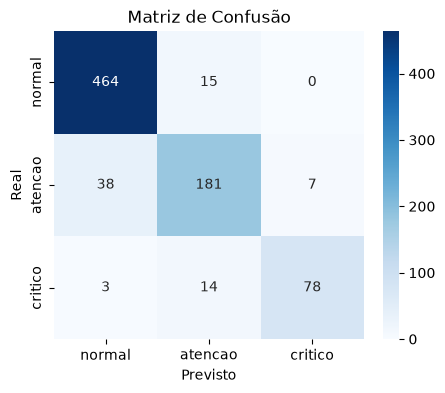

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = modelo.predict(X_test)

print("Acurácia:", round(accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred))

labels_ordenados = ["normal", "atencao", "critico"]
cm = confusion_matrix(y_test, y_pred, labels=labels_ordenados)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_ordenados, yticklabels=labels_ordenados)
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()


**Leitura dos resultados (com a seed fixa em 42, valores devem ficar próximos destes):**

- Acurácia geral em torno de **90%**.
- A classe `critico` tem boa precisão/recall — importante, porque **falso negativo em caso crítico é o erro mais caro** deste sistema (um alerta que deveria disparar e não dispara).
- A confusão concentra-se entre níveis **adjacentes** (`normal` ↔ `atencao`, `atencao` ↔ `critico`), quase não há confusão direta entre `normal` e `critico` — coerente com o ruído proposital que introduzimos nas fronteiras entre zonas.


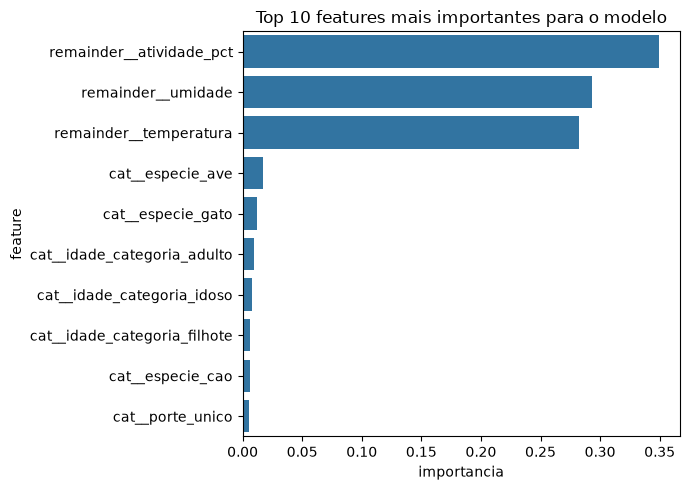

,feature,importancia
12,remainder__atividade_pct,0.349572
11,remainder__umidade,0.293489
10,remainder__temperatura,0.282246
0,cat__especie_ave,0.017000
2,cat__especie_gato,0.012300
7,cat__idade_categoria_adulto,0.009695
9,cat__idade_categoria_idoso,0.007958
8,cat__idade_categoria_filhote,0.006356
1,cat__especie_cao,0.005917
6,cat__porte_unico,0.005749


In [9]:
feature_names = modelo.named_steps["preprocessador"].get_feature_names_out()
importancias = modelo.named_steps["classificador"].feature_importances_

imp_df = pd.DataFrame({"feature": feature_names, "importancia": importancias}) \
    .sort_values("importancia", ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(data=imp_df.head(10), x="importancia", y="feature")
plt.title("Top 10 features mais importantes para o modelo")
plt.tight_layout()
plt.show()

imp_df.head(10)


**Leitura:** as três leituras diretas da coleira (`temperatura`, `umidade`, `atividade_pct`) dominam a decisão do modelo — o que faz sentido, são o sinal mais direto do estado do animal. `especie` e `idade_categoria` aparecem com peso menor, mas não nulo: é exatamente aí que mora a **personalização** — o modelo não decide igual para todo bicho, ele ajusta a decisão de acordo com o perfil.


## 6. Simulação de uma Chamada da API

Testamos o modelo com um payload no mesmo formato que a futura API Flask vai receber (dados vindos da coleira + perfil do animal cadastrado no app).


In [10]:
exemplo = pd.DataFrame([{
    "especie": "ave",
    "porte": "unico",
    "idade_categoria": "filhote",
    "temperatura": 41.0,
    "umidade": 35.0,
    "atividade_pct": 8.0,
}])

predicao = modelo.predict(exemplo)[0]
probabilidades = dict(zip(modelo.classes_, modelo.predict_proba(exemplo)[0].round(3)))

print("Cenário: ave filhote, com febre e baixa atividade")
print("Nível de risco previsto:", predicao)
print("Probabilidades por classe:", probabilidades)


Cenário: ave filhote, com febre e baixa atividade
Nível de risco previsto: critico
Probabilidades por classe: {'atencao': np.float64(0.314), 'critico': np.float64(0.673), 'normal': np.float64(0.014)}


## 7. Exportando o Modelo (.pkl)

O `Pipeline` completo (pré-processamento + classificador) é salvo em um único arquivo. A API Flask (próxima etapa, seguindo o mesmo fluxo da CP4: Flask → Docker → `/predict`) só precisa carregar este arquivo e chamar `.predict()` — sem reescrever nenhuma lógica de encoding.


In [11]:
import joblib

joblib.dump(modelo, "modelo_risco_pet.pkl")
print("Modelo salvo em modelo_risco_pet.pkl")


Modelo salvo em modelo_risco_pet.pkl


## 8. Próximos Passos

- **Integrar com a API Flask + Docker** (mesmo fluxo da CP4): endpoint `POST /predict` recebendo o JSON de leitura da coleira + perfil do pet, retornando `nivel_risco` e `probabilidades`.
- **Conectar com dados reais da coleira** (hoje simulados no Wokwi) via HTTP/MQTT, substituindo a geração sintética por leituras reais ao longo do tempo.
- **Camada de regras sobre a predição**, traduzindo o nível de risco em ação (`critico` → notificar tutor + sugerir consulta na clínica; `atencao` → monitorar; `normal` → nenhuma ação).
- **Modelo específico para répteis**, considerando a dependência da temperatura ambiente (ectotermia) — fora do escopo deste modelo por serem fisiologicamente incompatíveis com a lógica atual.
- **Retreino periódico** incorporando dados reais rotulados por veterinários, à medida que a base de uso cresce.
